Sala: 8 x 8
Ingenieros: [(2, 2), (5, 1), (6, 6), (1, 5), (4, 7), (7, 3)]
Iniciando evolución...

Generación   0 | mejor aptitud =   9.76 | promedio =   0.37
Generación   5 | mejor aptitud =   9.88 | promedio =   3.24
Generación  10 | mejor aptitud =  19.20 | promedio =   3.34
Generación  15 | mejor aptitud =  19.50 | promedio =   5.58
Generación  20 | mejor aptitud =  19.64 | promedio =   6.94
Generación  25 | mejor aptitud =  29.40 | promedio =   9.07
Generación  30 | mejor aptitud =  29.40 | promedio =   8.49
Generación  35 | mejor aptitud =  29.40 | promedio =   8.37
Generación  40 | mejor aptitud =  29.48 | promedio =   8.85
Generación  45 | mejor aptitud =  29.48 | promedio =  12.02
Generación  50 | mejor aptitud =  29.48 | promedio =   8.39
Generación  55 | mejor aptitud =  29.48 | promedio =  13.12
Generación  59 | mejor aptitud =  29.48 | promedio =  10.40

=== RESULTADO FINAL ===
Mejor aptitud encontrada : 29.48
Tamaño del árbol         : 26 nodos
Profundidad del árbol    : 7


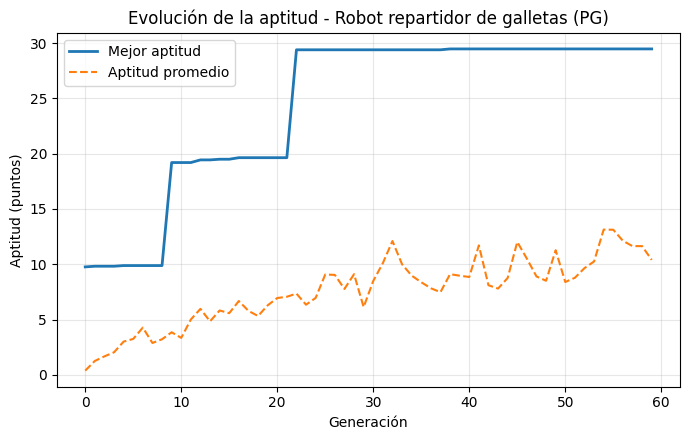

In [1]:
import random
import copy
import matplotlib.pyplot as plt


# CONFIGURACION (paso 5: parámetros de control de la corrida)


TAMANO_SALA = 8            # sala cuadrada de TAMANO_SALA x TAMANO_SALA
MAX_PASOS = 60              # pasos disponibles por corrida del robot
TAM_POBLACION = 80
NUM_GENERACIONES = 60
PROB_CRUCE = 0.8
PROB_MUTACION = 0.2
TAM_TORNEO = 3
NUM_ELITE = 2               # elitismo: mejores individuos que pasan directo
PROFUNDIDAD_INICIAL = 4
PROFUNDIDAD_MAXIMA = 7      # límite para evitar crecimiento excesivo (bloat)
PENALIZACION_TAMANO = 0.02  # castiga árboles innecesariamente grandes


# Ingenieros: posición (x, y) y puntos que otorgan al ser atendidos
INGENIEROS_INICIALES = [
    {"x": 2, "y": 2, "puntos": 10},
    {"x": 5, "y": 1, "puntos": 10},
    {"x": 6, "y": 6, "puntos": 10},
    {"x": 1, "y": 5, "puntos": 10},
    {"x": 4, "y": 7, "puntos": 10},
    {"x": 7, "y": 3, "puntos": 10},
]


# Direcciones: 0=Norte, 1=Este, 2=Sur, 3=Oeste (sentido horario)
DIRECCIONES = [(0, -1), (1, 0), (0, 1), (-1, 0)]
NOMBRE_DIRECCION = ["N", "E", "S", "O"]




# MODELO DEL MUNDO: SALA CUADRADA Y ROBOT


class Sala:
    def __init__(self, tamano, ingenieros):
        self.tamano = tamano
        # copia profunda para no modificar la lista original entre corridas
        self.ingenieros = [dict(i, servido=False) for i in ingenieros]
        self.puntos_obtenidos = 0


    def ingeniero_en(self, x, y):
        for ing in self.ingenieros:
            if not ing["servido"] and ing["x"] == x and ing["y"] == y:
                return ing
        return None


class Robot:
    def __init__(self, x=0, y=0, direccion=0):
        self.x = x
        self.y = y
        self.direccion = direccion  # índice en DIRECCIONES
        self.camino = [(x, y)]      # para poder visualizar el recorrido




# PASO 2: CONJUNTO DE TERMINALES (acciones atómicas, aridad 0)


TERMINALES = ["avanza", "gira_izquierda", "gira_derecha", "entrega_galleta"]




def avanza(robot, sala, contador):
    if contador[0] <= 0:
        return
    contador[0] -= 1
    dx, dy = DIRECCIONES[robot.direccion]
    nx, ny = robot.x + dx, robot.y + dy
    if 0 <= nx < sala.tamano and 0 <= ny < sala.tamano:
        robot.x, robot.y = nx, ny
    robot.camino.append((robot.x, robot.y))




def gira_izquierda(robot, sala, contador):
    if contador[0] <= 0:
        return
    contador[0] -= 1
    robot.direccion = (robot.direccion - 1) % 4




def gira_derecha(robot, sala, contador):
    if contador[0] <= 0:
        return
    contador[0] -= 1
    robot.direccion = (robot.direccion + 1) % 4




def entrega_galleta(robot, sala, contador):
    if contador[0] <= 0:
        return
    contador[0] -= 1
    ing = sala.ingeniero_en(robot.x, robot.y)
    if ing is not None:
        ing["servido"] = True
        sala.puntos_obtenidos += ing["puntos"]




ACCIONES_TERMINALES = {
    "avanza": avanza,
    "gira_izquierda": gira_izquierda,
    "gira_derecha": gira_derecha,
    "entrega_galleta": entrega_galleta,
}




# PASO 3: CONJUNTO DE FUNCIONES PRIMITIVAS (aridad > 0)


FUNCIONES = {
    "si_ingeniero_adelante": 2,
    "secuencia2": 2,
    "secuencia3": 3,
}




def ingeniero_adelante(robot, sala):
    dx, dy = DIRECCIONES[robot.direccion]
    nx, ny = robot.x + dx, robot.y + dy
    if not (0 <= nx < sala.tamano and 0 <= ny < sala.tamano):
        return False
    return sala.ingeniero_en(nx, ny) is not None






# REPRESENTACION DEL ARBOL (cromosoma): (nombre, [hijos])


def generar_arbol(prof_max, metodo="grow", prof_actual=0):
    """Genera un árbol aleatorio (equivalente a Genera_Subárbol del
    documento, aplicado recursivamente)."""
    en_hoja = prof_actual >= prof_max or (
        metodo == "grow" and prof_actual > 0 and random.random() < 0.35
    )
    if en_hoja:
        return (random.choice(TERMINALES), [])
    nombre = random.choice(list(FUNCIONES.keys()))
    aridad = FUNCIONES[nombre]
    hijos = [generar_arbol(prof_max, metodo, prof_actual + 1) for _ in range(aridad)]
    return (nombre, hijos)




def generar_poblacion_inicial(tam_poblacion, prof_max):
    """Ramped half-and-half simplificado: mitad con método 'full',
    mitad con método 'grow', variando la profundidad máxima."""
    poblacion = []
    for i in range(tam_poblacion):
        metodo = "full" if i % 2 == 0 else "grow"
        profundidad = random.randint(2, prof_max)
        poblacion.append(generar_arbol(profundidad, metodo))
    return poblacion




def ejecutar(nodo, robot, sala, contador):
    """Ejecuta (interpreta) el árbol-programa sobre el robot."""
    if contador[0] <= 0:
        return
    nombre, hijos = nodo
    if nombre in ACCIONES_TERMINALES:
        ACCIONES_TERMINALES[nombre](robot, sala, contador)
    elif nombre == "secuencia2":
        ejecutar(hijos[0], robot, sala, contador)
        ejecutar(hijos[1], robot, sala, contador)
    elif nombre == "secuencia3":
        for h in hijos:
            ejecutar(h, robot, sala, contador)
    elif nombre == "si_ingeniero_adelante":
        if ingeniero_adelante(robot, sala):
            ejecutar(hijos[0], robot, sala, contador)
        else:
            ejecutar(hijos[1], robot, sala, contador)
    else:
        raise ValueError(f"Nodo desconocido: {nombre}")




def contar_nodos(nodo):
    nombre, hijos = nodo
    return 1 + sum(contar_nodos(h) for h in hijos)




def profundidad(nodo):
    nombre, hijos = nodo
    if not hijos:
        return 1
    return 1 + max(profundidad(h) for h in hijos)




def arbol_a_texto(nodo):
    nombre, hijos = nodo
    if not hijos:
        return nombre
    return f"{nombre}(" + ", ".join(arbol_a_texto(h) for h in hijos) + ")"




# PASO 4: FUNCION DE APTITUD


def evaluar_aptitud(arbol, tamano_sala=TAMANO_SALA,
                     ingenieros_iniciales=INGENIEROS_INICIALES,
                     max_pasos=MAX_PASOS, registrar_camino=False):
    """Corre el robot controlado por 'arbol' dentro de la sala y devuelve
    los puntos obtenidos, penalizados levemente por el tamaño del árbol."""
    sala = Sala(tamano_sala, ingenieros_iniciales)
    robot = Robot(0, 0, 0)
    contador = [max_pasos]


    # El árbol se ejecuta repetidamente (como un bucle de control) hasta
    # agotar los pasos disponibles, igual que en el problema clásico del
    # "hormiga de Santa Fe" en PG.
    while contador[0] > 0:
        antes = contador[0]
        ejecutar(arbol, robot, sala, contador)
        if contador[0] == antes:
            # el árbol no consumió ningún paso (caso degenerado) -> evitar bucle infinito
            break


    aptitud = sala.puntos_obtenidos - PENALIZACION_TAMANO * contar_nodos(arbol)


    if registrar_camino:
        return aptitud, sala, robot
    return aptitud






# OPERADORES GENETICOS: SELECCION, CRUCE Y MUTACION


def seleccion_torneo(poblacion, aptitudes, k=TAM_TORNEO):
    participantes = random.sample(range(len(poblacion)), k)
    mejor = max(participantes, key=lambda i: aptitudes[i])
    return poblacion[mejor]




def obtener_caminos(nodo, camino_actual=()):
    """Devuelve la lista de 'caminos' (rutas de índices) hacia cada nodo
    del árbol, recorriéndolo en preorden (igual que en la sección 4.7 del
    documento, donde se numeran los nodos en preorden para el cruce)."""
    caminos = [camino_actual]
    _, hijos = nodo
    for i, h in enumerate(hijos):
        caminos.extend(obtener_caminos(h, camino_actual + (i,)))
    return caminos




def obtener_subarbol(arbol, camino):
    nodo = arbol
    for i in camino:
        nodo = nodo[1][i]
    return nodo




def reemplazar_subarbol(arbol, camino, nuevo_subarbol):
    if not camino:
        return copy.deepcopy(nuevo_subarbol)
    nombre, hijos = arbol
    hijos = list(hijos)
    idx = camino[0]
    hijos[idx] = reemplazar_subarbol(hijos[idx], camino[1:], nuevo_subarbol)
    return (nombre, hijos)




def cruce(padre1, padre2, prof_maxima=PROFUNDIDAD_MAXIMA):
    """Cruce de árboles (sección 4.7): se elige un punto de cruce
    aleatorio en cada padre y se intercambian los subárboles."""
    p1 = copy.deepcopy(padre1)
    p2 = copy.deepcopy(padre2)
    camino1 = random.choice(obtener_caminos(p1))
    camino2 = random.choice(obtener_caminos(p2))
    sub1 = obtener_subarbol(p1, camino1)
    sub2 = obtener_subarbol(p2, camino2)
    hijo1 = reemplazar_subarbol(p1, camino1, sub2)
    hijo2 = reemplazar_subarbol(p2, camino2, sub1)
    # control de crecimiento excesivo de profundidad (ver comentario del
    # documento tras la figura 4.4)
    if profundidad(hijo1) > prof_maxima:
        hijo1 = p1
    if profundidad(hijo2) > prof_maxima:
        hijo2 = p2
    return hijo1, hijo2




def mutacion(arbol, prof_maxima=PROFUNDIDAD_MAXIMA, prof_subarbol_nuevo=3):
    """Reemplaza un subárbol elegido al azar por uno nuevo generado
    aleatoriamente (equivalente al cambio de gen descrito en el
    documento)."""
    nuevo = copy.deepcopy(arbol)
    camino = random.choice(obtener_caminos(nuevo))
    subarbol_nuevo = generar_arbol(prof_subarbol_nuevo, "grow")
    resultado = reemplazar_subarbol(nuevo, camino, subarbol_nuevo)
    if profundidad(resultado) > prof_maxima:
        return arbol
    return resultado






# ALGORITMO PRINCIPAL DE PG (sección 4.3: pasos 1-3 del algoritmo general)


def algoritmo_pg():
    poblacion = generar_poblacion_inicial(TAM_POBLACION, PROFUNDIDAD_INICIAL)
    historial_mejor = []
    historial_promedio = []
    mejor_individuo_global = None
    mejor_aptitud_global = float("-inf")


    for gen in range(NUM_GENERACIONES):
        aptitudes = [evaluar_aptitud(ind) for ind in poblacion]


        idx_ordenados = sorted(range(len(poblacion)), key=lambda i: aptitudes[i], reverse=True)
        mejor_gen = aptitudes[idx_ordenados[0]]
        promedio_gen = sum(aptitudes) / len(aptitudes)
        historial_mejor.append(mejor_gen)
        historial_promedio.append(promedio_gen)


        if mejor_gen > mejor_aptitud_global:
            mejor_aptitud_global = mejor_gen
            mejor_individuo_global = copy.deepcopy(poblacion[idx_ordenados[0]])


        if gen % 5 == 0 or gen == NUM_GENERACIONES - 1:
            print(f"Generación {gen:3d} | mejor aptitud = {mejor_gen:6.2f} | promedio = {promedio_gen:6.2f}")


        # Elitismo: los mejores pasan directo a la siguiente generación
        nueva_poblacion = [copy.deepcopy(poblacion[i]) for i in idx_ordenados[:NUM_ELITE]]


        # Reproducción, cruce y mutación hasta completar la población
        while len(nueva_poblacion) < TAM_POBLACION:
            padre1 = seleccion_torneo(poblacion, aptitudes)
            padre2 = seleccion_torneo(poblacion, aptitudes)


            if random.random() < PROB_CRUCE:
                hijo1, hijo2 = cruce(padre1, padre2)
            else:
                hijo1, hijo2 = copy.deepcopy(padre1), copy.deepcopy(padre2)


            if random.random() < PROB_MUTACION:
                hijo1 = mutacion(hijo1)
            if random.random() < PROB_MUTACION:
                hijo2 = mutacion(hijo2)


            nueva_poblacion.append(hijo1)
            if len(nueva_poblacion) < TAM_POBLACION:
                nueva_poblacion.append(hijo2)


        poblacion = nueva_poblacion


    return mejor_individuo_global, mejor_aptitud_global, historial_mejor, historial_promedio




# VISUALIZACION DEL RESULTADO


def dibujar_sala(sala, robot, tamano):
    print("\nRecorrido final del robot (S = inicio, R = robot, I = ingeniero servido, i = sin servir):")
    for y in range(tamano):
        fila = ""
        for x in range(tamano):
            ing = None
            for i in sala.ingenieros:
                if i["x"] == x and i["y"] == y:
                    ing = i
            if x == robot.x and y == robot.y:
                fila += " R "
            elif ing is not None:
                fila += " I " if ing["servido"] else " i "
            elif (x, y) == (0, 0):
                fila += " S "
            else:
                fila += " . "
        print(fila)


def graficar_evolucion(historial_mejor, historial_promedio, ruta_salida):
    plt.figure(figsize=(7, 4.5))
    plt.plot(historial_mejor, label="Mejor aptitud", linewidth=2)
    plt.plot(historial_promedio, label="Aptitud promedio", linestyle="--")
    plt.xlabel("Generación")
    plt.ylabel("Aptitud (puntos)")
    plt.title("Evolución de la aptitud - Robot repartidor de galletas (PG)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(ruta_salida, dpi=150)
    print(f"\nGráfica de evolución guardada en: {ruta_salida}")




if __name__ == "__main__":
    random.seed(42)  # reproducibilidad


    print("Sala:", TAMANO_SALA, "x", TAMANO_SALA)
    print("Ingenieros:", [(i["x"], i["y"]) for i in INGENIEROS_INICIALES])
    print("Iniciando evolución...\n")


    mejor_arbol, mejor_aptitud, hist_mejor, hist_prom = algoritmo_pg()


    print("\n=== RESULTADO FINAL ===")
    print("Mejor aptitud encontrada :", round(mejor_aptitud, 2))
    print("Tamaño del árbol         :", contar_nodos(mejor_arbol), "nodos")
    print("Profundidad del árbol    :", profundidad(mejor_arbol))
    print("Programa (preorden)      :", arbol_a_texto(mejor_arbol))


    aptitud_final, sala_final, robot_final = evaluar_aptitud(
        mejor_arbol, registrar_camino=True
    )
    ingenieros_servidos = sum(1 for i in sala_final.ingenieros if i["servido"])
    print(f"Ingenieros atendidos     : {ingenieros_servidos} de {len(sala_final.ingenieros)}")
    print(f"Puntos obtenidos         : {sala_final.puntos_obtenidos}")


    dibujar_sala(sala_final, robot_final, TAMANO_SALA)
    graficar_evolucion(hist_mejor, hist_prom, "evolucion_aptitud.png")
